## Importing Libraries


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# sns.set()


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score


from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
import warnings
warnings.filterwarnings("ignore")

##### Data Source:
- https://www.kaggle.com/datasets/abdullah0a/telecom-customer-churn-insights-for-analysis

### Data Importing & Inspecting

In [ ]:
df=pd.read_csv("customer_churn_data.csv")

In [ ]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


### Data Preparation & Exploration

In [ ]:
df.isna().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
MonthlyCharges,0
ContractType,0
InternetService,297
TotalCharges,0
TechSupport,0
Churn,0


In [ ]:
df.isna().sum().sum()

np.int64(297)

In [ ]:
df.head(2)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.0,Yes,Yes


In [ ]:
df["InternetService"]=df["InternetService"].fillna("")

In [ ]:
df.isna().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [ ]:
numeric_column_data=df.select_dtypes(include=["number"])

In [ ]:
numeric_column_data.corr()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
CustomerID,1.000000,0.036730,-0.018585,-0.030504,-0.027490
Age,0.036730,1.000000,0.000472,0.006362,-0.001896
Tenure,-0.018585,0.000472,1.000000,-0.014552,0.894868
MonthlyCharges,-0.030504,0.006362,-0.014552,1.000000,0.304893
TotalCharges,-0.027490,-0.001896,0.894868,0.304893,1.000000


In [ ]:
df.head(2)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.0,Yes,Yes


In [ ]:
df["Churn"].value_counts()

,count
Churn,
Yes,883
No,117


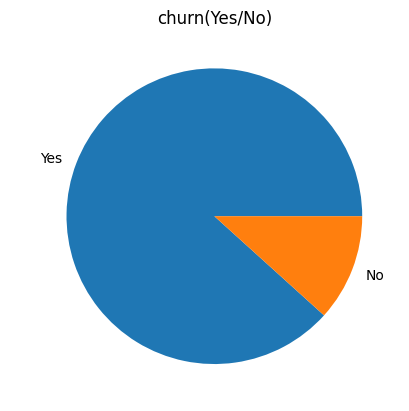

In [ ]:
df["Churn"].value_counts().plot(kind="pie")
plt.title ("churn(Yes/No)")
plt.ylabel(" ")
plt.show()

In [ ]:
df.head(2)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.0,Yes,Yes


In [ ]:
df.groupby("Churn")["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
No,62.54641
Yes,75.96077


In [ ]:
df.groupby(["Churn","Gender"])["MonthlyCharges"].mean()

Churn  Gender
No     Female    65.091912
       Male      59.013878
Yes    Female    74.975064
       Male      77.082518
Name: MonthlyCharges, dtype: float64

In [ ]:
df.groupby("Churn")["Tenure"].mean()

,Tenure
Churn,
No,30.264957
Yes,17.476784


In [ ]:
df.groupby("Churn")["Age"].mean()

,Age
Churn,
No,43.487179
Yes,44.831257


At the lower terms we can see that the monthly charge average decrases

In [ ]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges',
       'ContractType', 'InternetService', 'TotalCharges', 'TechSupport',
       'Churn'],
      dtype='object')

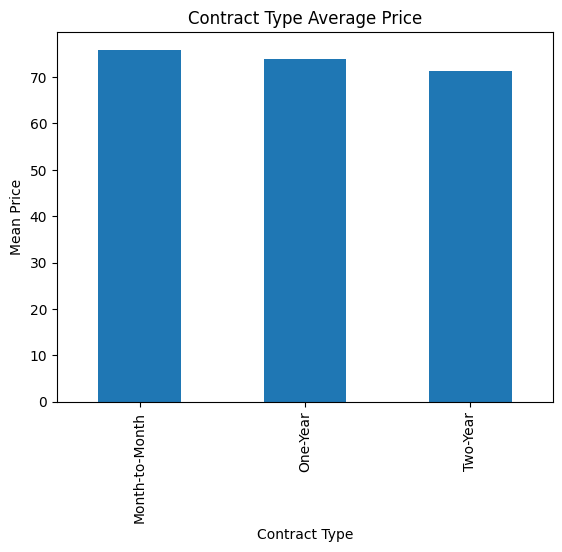

In [ ]:
df.groupby("ContractType")["MonthlyCharges"].mean().plot(kind="bar")
plt.ylabel("Mean Price")
plt.xlabel("Contract Type")
plt.title("Contract Type Average Price")
plt.show()

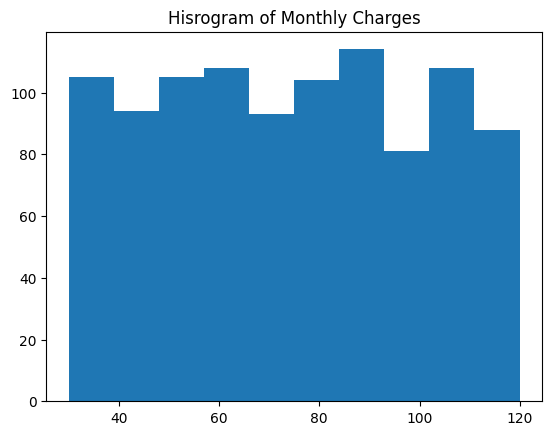

In [ ]:
plt.hist(df["MonthlyCharges"])
plt.title("Hisrogram of Monthly Charges")
plt.show()

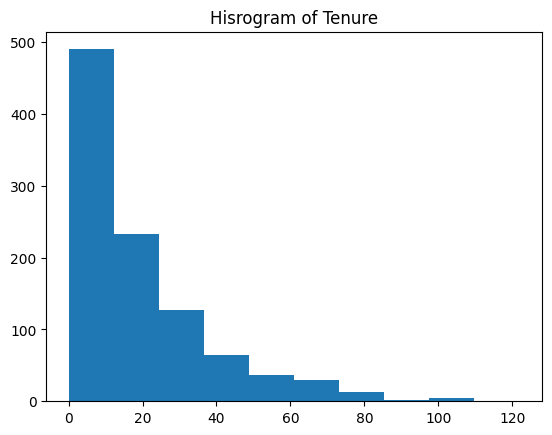

In [ ]:
plt.hist(df["Tenure"])
plt.title("Hisrogram of Tenure")
plt.show()

In [ ]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,,2208.32,No,Yes


In [ ]:
df.head(1)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes


In [ ]:
y=df[['Churn']]
X=df[["Age","Gender","Tenure","MonthlyCharges"]]

In [ ]:
y.head()


,Churn
0,Yes
1,Yes
2,Yes
3,Yes
4,Yes


In [ ]:
X.head()

,Age,Gender,Tenure,MonthlyCharges
0,49,Male,4,88.35
1,43,Male,0,36.67
2,51,Female,2,63.79
3,60,Female,8,102.34
4,42,Male,32,69.01


In [ ]:
X['Gender']=X['Gender'].apply(lambda x: 1 if x=="Female" else 0)       #

In [ ]:
X.head()

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,1,2,63.79
3,60,1,8,102.34
4,42,0,32,69.01


In [ ]:
y["Churn"]= y["Churn"].apply(lambda x: 1 if x== "Yes" else 0)       #

In [ ]:
y["Churn"].head()

,Churn
0,1
1,1
2,1
3,1
4,1


In [ ]:
type(y["Churn"][0])

numpy.int64

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2)

In [ ]:
scalar=StandardScaler()

In [ ]:
 X_train=scalar.fit_transform(X_train)

In [ ]:
X_train

array([[ 1.25382672,  0.90453403, -0.99267843,  1.42177181],
       [ 1.04851275, -1.1055416 ,  1.28078591, -0.92196139],
       [ 0.53522784, -1.1055416 , -0.07246668,  1.74666493],
       ...,
       [ 0.02194293, -1.1055416 ,  2.25512776, -1.32254646],
       [ 0.53522784, -1.1055416 , -0.93854833, -0.7018725 ],
       [ 0.63788482,  0.90453403,  1.38904611, -1.51895736]])

In [ ]:
import joblib
joblib.dump(scalar, "scalar.pkl")

['scalar.pkl']

In [ ]:
X_test =scalar.fit_transform(X_test)

In [ ]:
X_test

array([[ 0.87888809, -0.98019606,  2.09930241,  0.81597577],
       [-0.42316834,  1.02020406,  0.76531406, -1.17070333],
       [-0.42316834,  1.02020406, -0.86511615,  1.70436984],
       [ 0.37809716,  1.02020406,  0.71590708, -0.26222589],
       [-1.22443384, -0.98019606, -0.61808127, -0.31184364],
       [-1.62506659,  1.02020406,  0.51827918,  0.44778054],
       [ 0.67857172, -0.98019606, -0.12401151,  0.19220973],
       [ 0.27793897,  1.02020406,  1.9016745 , -0.65838034],
       [ 1.78031177, -0.98019606, -0.7663022 ,  1.80793705],
       [-0.42316834,  1.02020406, -1.06274405, -1.51251452],
       [ 0.87888809, -0.98019606,  2.09930241,  1.02547295],
       [-0.32301015,  1.02020406, -0.7663022 , -0.12361121],
       [ 0.67857172,  1.02020406,  1.35819777,  1.40233161],
       [ 2.18094452,  1.02020406, -1.06274405,  0.51945063],
       [-1.5249084 ,  1.02020406,  0.71590708,  0.44147987],
       [-0.22285197, -0.98019606, -0.42045337, -0.80211431],
       [-0.02253559,  1.

In [ ]:
def modelperformance(prodiction):
  print("Accuracy score on model is {}".format(accuracy_score(y_test,prodiction )))

In [ ]:
log_model = LogisticRegression()

In [ ]:
log_model.fit(X_train,y_train)

LogisticRegression()

In [ ]:
y_pred=log_model.predict(X_test)

In [ ]:
modelperformance(y_pred)

Accuracy score on model is 0.88


In [ ]:
param_grid ={
    "n_neighbors": [3,5,7,9],
    "weights" : ["uniform","distance"],
}

In [ ]:
gridkn = GridSearchCV(KNeighborsClassifier(),param_grid,cv= 5)

In [ ]:
gridkn.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']})

In [ ]:
gridkn.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']})

In [ ]:
gridkn.best_params_

{'n_neighbors': 7, 'weights': 'distance'}

In [ ]:
y_pred = gridkn.predict(X_test)

In [ ]:
modelperformance(y_pred)

Accuracy score on model is 0.865


In [ ]:
svm = SVC()

In [ ]:
param_grid={
    "C": [0.01,0.1,0.5,1] ,
    "kernel": ["linear","rbf","poly"]
}

In [ ]:
gridsvc = GridSearchCV(svm, param_grid,cv =5)

In [ ]:
gridsvc.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.01, 0.1, 0.5, 1],
                         'kernel': ['linear', 'rbf', 'poly']})

In [ ]:
gridsvc.best_params_

{'C': 0.01, 'kernel': 'linear'}

In [ ]:
y_pred=gridsvc.predict(X_test)

In [ ]:
modelperformance(y_pred)

Accuracy score on model is 0.885


In [ ]:
param_grid ={
    "criterion" :["gini","entropy"],
    "splitter":["best","random"],
    "max_depth" : [None,10,20,30],
    "min_samples_split":[2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [ ]:
grid_tree=GridSearchCV(DecisionTreeClassifier(),param_grid,cv =5)

In [ ]:
grid_tree.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']})

In [ ]:
grid_tree.best_params_

{'criterion': 'entropy',
 'max_depth': 10,
 'min_samples_leaf': 2,
 'min_samples_split': 10,
 'splitter': 'best'}

In [ ]:
y_pred=grid_tree.predict(X_test)

In [ ]:
y_pred

array([1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1])

In [ ]:
modelperformance(y_pred)

Accuracy score on model is 0.86


In [ ]:
rfc_model =RandomForestClassifier()

In [ ]:
param_grid ={
    "n_estimators": [32,64,120,256],
    "max_features":  [2,3,4],
    "bootstrap": [True,False]
}

In [ ]:
grid_rfc=GridSearchCV(rfc_model,param_grid, cv = 5)

In [ ]:
grid_rfc.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False], 'max_features': [2, 3, 4],
                         'n_estimators': [32, 64, 120, 256]})

In [ ]:
grid_rfc.best_params_

{'bootstrap': True, 'max_features': 3, 'n_estimators': 120}

In [ ]:
y_pred=grid_rfc.predict(X_test)

In [ ]:
modelperformance(y_pred)

Accuracy score on model is 0.855


In [ ]:
best_model =gridsvc.best_estimator_

In [ ]:
joblib.dump(best_model,"model.pkl")

['model.pkl']

In [ ]:
X.columns

Index(['Age', 'Gender', 'Tenure', 'MonthlyCharges'], dtype='object')